In [16]:
!pip install librosa tensorflow scikit-learn seaborn joblib -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [18]:
DATA_PATH = "../data/audio/ravdess"

In [19]:
emotion_map = {
    "01": "Neutral",      # neutral
    "02": "Neutral",      # calm
    "03": "Positive",     # happy
    "04": "Depression",   # sad
    "05": "Stress",       # angry
    "06": "Anxiety",      # fearful
    "07": "Negative",     # disgust
    "08": "Neutral"       # surprised
}


In [20]:
def extract_features(file_path):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.mean(mfcc.T, axis=0)
    return mfcc

In [21]:
X = []
y = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".wav"):
            path = os.path.join(root, file)

            parts = file.split("-")
            code = parts[2]

            label = emotion_map[code]
            feat = extract_features(path)

            X.append(feat)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Samples:", len(X))
print("Feature Shape:", X.shape)
print("Classes:", set(y))

Samples: 2880
Feature Shape: (2880, 40)
Classes: {np.str_('Neutral'), np.str_('Anxiety'), np.str_('Stress'), np.str_('Depression'), np.str_('Positive'), np.str_('Negative')}


In [22]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

print("Classes Order:", encoder.classes_)

Classes Order: ['Anxiety' 'Depression' 'Negative' 'Neutral' 'Positive' 'Stress']


In [23]:
X = X.reshape(X.shape[0], X.shape[1], 1)
print("New Shape:", X.shape)

New Shape: (2880, 40, 1)


In [24]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_cat
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (2304, 40, 1)
Val  : (288, 40, 1)
Test : (288, 40, 1)


In [25]:
model = Sequential()

model.add(Conv1D(64, kernel_size=3, activation="relu", input_shape=(40,1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dense(6, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\prasa\OneDrive\Desktop\BE\backend\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,830 (147.77 KB)

 Trainable params: 37,830 (147.77 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../models/speech_final_6_best.h5",
        save_best_only=True
    )
]

In [27]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/60
68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3033 - loss: 1.7343

72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3303 - loss: 1.7088 - val_accuracy: 0.3333 - val_loss: 1.6750
Epoch 2/60
65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3448 - loss: 1.6643

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3411 - loss: 1.6731 - val_accuracy: 0.3646 - val_loss: 1.6486
Epoch 3/60
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3533 - loss: 1.6379

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3650 - loss: 1.6269 - val_accuracy: 0.3889 - val_loss: 1.5876
Epoch 4/60
68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3851 - loss: 1.5838

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3733 - loss: 1.5835 - val_accuracy: 0.3958 - val_loss: 1.5869
Epoch 5/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3834 - loss: 1.5542 

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6923 - loss: 0.7968 - val_accuracy: 0.7049 - val_loss: 0.8266
Epoch 40/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6992 - loss: 0.7814 - val_accuracy: 0.6910 - val_loss: 0.8275
Epoch 41/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7192 - loss: 0.7700 - val_accuracy: 0.6979 - val_loss: 0.8395
Epoch 42/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7337 - loss: 0.7136

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7231 - loss: 0.7317 - val_accuracy: 0.7222 - val_loss: 0.7900
Epoch 43/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7335 - loss: 0.7111 - val_accuracy: 0.7292 - val_loss: 0.7907
Epoch 44/60
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7318 - loss: 0.7184

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7283 - loss: 0.7401 - val_accuracy: 0.7153 - val_loss: 0.7864
Epoch 45/60
68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7257 - loss: 0.7245

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7344 - loss: 0.6984 - val_accuracy: 0.7326 - val_loss: 0.7196
Epoch 46/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7470 - loss: 0.6979 - val_accuracy: 0.7535 - val_loss: 0.7385
Epoch 47/60
68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7795 - loss: 0.6472

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7622 - loss: 0.6698 - val_accuracy: 0.7639 - val_loss: 0.7073
Epoch 48/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7556 - loss: 0.6627 - val_accuracy: 0.7292 - val_loss: 0.7385
Epoch 49/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7639 - loss: 0.6437 - val_accuracy: 0.7118 - val_loss: 0.7807
Epoch 50/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7687 - loss: 0.6374 - val_accuracy: 0.7431 - val_loss: 0.7359
Epoch 51/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7752 - loss: 0.6148 - val_accuracy: 0.7014 - val_loss: 0.8031
Epoch 52/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7786 - loss: 0.6082 - val_accuracy: 0.7292 - val_loss: 0.7379


In [28]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", round(acc,4))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7083 - loss: 0.8005 
Test Accuracy: 0.7083


In [29]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


In [30]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.7083
Precision: 0.7042
Recall   : 0.7083
F1 Score : 0.7035


In [31]:
print(classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

     Anxiety       0.68      0.71      0.69        38
  Depression       0.58      0.46      0.51        39
    Negative       0.70      0.61      0.65        38
     Neutral       0.75      0.84      0.79        96
    Positive       0.68      0.74      0.71        38
      Stress       0.77      0.69      0.73        39

    accuracy                           0.71       288
   macro avg       0.69      0.68      0.68       288
weighted avg       0.70      0.71      0.70       288



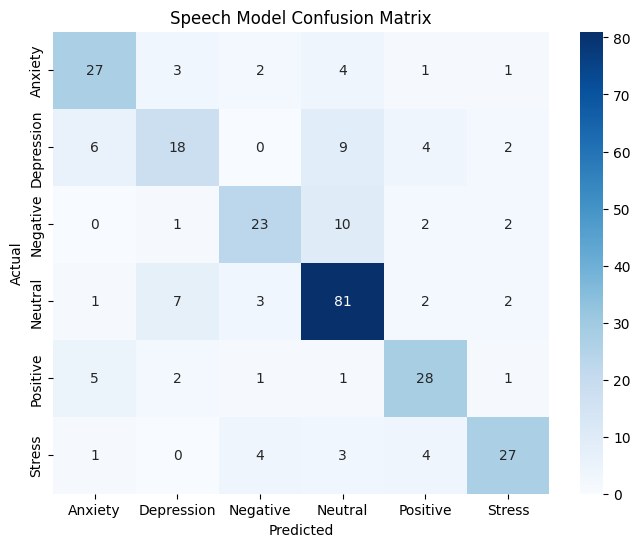

In [32]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Speech Model Confusion Matrix")
plt.show()

In [33]:
model.save("../models/speech_final_6.h5")
joblib.dump(encoder, "../models/speech_label_encoder.pkl")

['../models/speech_label_encoder.pkl']

In [46]:
from tensorflow.keras.models import load_model
import joblib
import numpy as np

loaded_model = load_model("../models/speech_final_6.h5")
encoder = joblib.load("../models/speech_label_encoder.pkl")

def predict_audio(file_path):
    feat = extract_features(file_path)
    feat = feat.reshape(1, 40, 1)

    pred = loaded_model.predict(feat, verbose=0)

    idx = np.argmax(pred)
    label = encoder.inverse_transform([idx])[0]
    conf = float(np.max(pred))

    print("Prediction:", label)
    print("Confidence:", round(conf, 4))

# TEST
predict_audio("../data/audio/ravdess/Actor_01/03-01-08-01-01-01-01.wav")

Prediction: Neutral
Confidence: 0.73


In [47]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ]
})

print(metrics_table)

      Metric   Score
0   Accuracy  0.7083
1  Precision  0.7042
2     Recall  0.7083
3   F1-Score  0.7035
